Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [77]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [78]:
# Load the automobile dataset
automobiles_df = pd.read_csv('automobile.txt', sep=",")

# check what you have
print(type(automobiles_df)) 
print(automobiles_df.columns)
automobiles_df.head()
automobiles_df.shape

<class 'pandas.core.frame.DataFrame'>
Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')


(205, 26)

 **Introduction**
This exploratory data analysis examines a dataset of 205 automobiles to identify key trends and patterns in vehicle specifications, pricing, and performance. The analysis focuses on understanding relationships between vehicle attributes such as engine capacity, fuel efficiency, pricing, and manufacturer characteristics.

In [79]:
#understand the data and what yuou have
automobiles_df.info()
automobiles_df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205,205,205.000000,205,205,205.000000,205.000000,205
unique,NaN,52,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,187
top,NaN,?,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.40,NaN,68,5500,NaN,NaN,?
freq,NaN,41,32,185,168,114,96,120,202,NaN,...,NaN,94,23,20,NaN,19,37,NaN,NaN,4
mean,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,NaN,NaN,10.142537,NaN,NaN,25.219512,30.751220,NaN
std,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,NaN,NaN,3.972040,NaN,NaN,6.542142,6.886443,NaN
min,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.600000,NaN,NaN,19.000000,25.000000,NaN
50%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.000000,NaN


The dataset has 205 rows and 26 columns. 
Quality Issues:
- Missing values in key columns (normalized-losses: 20%, horsepower, price)
- Non-standard missing value indicators ("?" instead of NaN)
- Inconsistent data types requiring conversion


### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [80]:
#check columns
print(automobiles_df.columns.tolist())

#drop normalized_losses and symboling
automobiles_df = automobiles_df.drop(['symboling', 'normalized-losses'], axis=1)


['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [81]:
#check hoe many columns you have
print(automobiles_df.shape) 
#view the data
automobiles_df.head()

(205, 24)


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


#### Remove any duplicate rows

In [82]:
# Code here

#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [83]:
# Code here
#check if there are any duplicated
automobiles_df.duplicated().sum()
automobiles_df.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [84]:
# List of columns to convert
cols_to_convert = ['horsepower', 'peak-rpm', 'price', 'wheel-base', 'length', 
                   'width', 'engine-size', 'bore', 'stroke', 'compression-ratio', 
                   'city-mpg', 'highway-mpg']

# Replace "?" with NaN
automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].replace('?', np.nan)

# Convert to numeric
automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

#Fill NaN with mean (THIS STEP IS CRITICAL!)
automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].fillna(automobiles_df[cols_to_convert].mean())

# Verify no NaN values remain
print("NaN values remaining:")
print(automobiles_df[cols_to_convert].isnull().sum())

# NOW convert to int
automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].astype(np.int64)

# Verify
print("\nData types:")
print(automobiles_df[cols_to_convert].dtypes)

NaN values remaining:
horsepower           0
peak-rpm             0
price                0
wheel-base           0
length               0
width                0
engine-size          0
bore                 0
stroke               0
compression-ratio    0
city-mpg             0
highway-mpg          0
dtype: int64

Data types:
horsepower           int64
peak-rpm             int64
price                int64
wheel-base           int64
length               int64
width                int64
engine-size          int64
bore                 int64
stroke               int64
compression-ratio    int64
city-mpg             int64
highway-mpg          int64
dtype: object


### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [85]:
# Create a dataframe with all the cars in the "hatchback' category
# hatchback_cars =
# Create new dataframe with only hatchbacks
hatchback_df = automobiles_df[automobiles_df['body-style'] == 'hatchback']

# Verify
print(hatchback_df.shape)
hatchback_df.head()

(70, 24)


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94,171,65,...,152,mpfi,2,3,9,154,5000,19,26,16500
9,audi,gas,turbo,two,hatchback,4wd,front,99,178,67,...,131,mpfi,3,3,7,160,5500,16,22,13207
18,chevrolet,gas,std,two,hatchback,fwd,front,88,141,60,...,61,2bbl,2,3,9,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94,155,63,...,90,2bbl,3,3,9,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,93,157,63,...,90,2bbl,2,3,9,68,5500,37,41,5572


2. **Data Cleaning**

2.1 Data Quality Assessment

Initial examination of the dataset revealed several data quality issues requiring attention:

**Issues Identified:**
- Missing values across multiple columns (normalized-losses: 20%, horsepower, bore, stroke, peak-rpm, price)
- Non-standard missing value indicators: "?" used instead of NaN
- Inconsistent data types: numeric columns stored as object/text types
- Presence of unnecessary columns for analysis (normalized-losses, symboling)

2.2 Data Cleaning Steps

**Step 1: Duplicate Check**
- Command: `automobiles_df.duplicated().sum()`
- Result: 0 duplicates found
- Action: No removal necessary

**Step 2: Missing Value Analysis**
- Command: `automobiles_df.isnull().sum()`
- Visualization: Created a summary showing count of missing values per column
- Key findings: Multiple columns contained significant missing data

**Step 3: Column Removal**
- Dropped redundant/unnecessary columns: 'normalized-losses' and 'symboling'
- Rationale: These columns would not be used in the analysis
- Command: `automobiles_df.drop(['normalized-losses', 'symboling'], axis=1)`

**Step 4: Handling Non-Standard Missing Values**
- Replaced "?" placeholders with NaN for proper handling
- Command: `automobiles_df.replace('?', np.nan)`
- Affected columns: horsepower, bore, stroke, peak-rpm, price
**Step 5: Data Type Conversion**
- Converted object-type columns to appropriate numeric types (int64)
- Columns converted: horsepower, peak-rpm, price, wheel-base, length, width, engine-size, bore, stroke, compression-ratio, city-mpg, highway-mpg
- Method: 
```python
  automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].replace('?', np.nan)
  automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].apply(pd.to_numeric)
  automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].fillna(mean/median)
  automobiles_df[cols_to_convert] = automobiles_df[cols_to_convert].astype(np.int64)
```

**Step 6: Missing Value Treatment**
- Strategy: Imputation using mean/median values
- Rationale: Preserved dataset size while maintaining statistical integrity

2.3 Data Cleaning Results

**Before Cleaning:**
- Shape: (205, 26)
- Data type issues: Multiple object columns containing numeric data
- Missing values: Present across multiple columns

**After Cleaning:**
- Shape: (205, 24) - removed 2 unnecessary columns
- All numeric columns properly typed as int64/float64
- Missing values: Handled through imputation
- Dataset ready for analysis

 2.4 Visualizations During Data Cleaning

**Initial Data Assessment:**
- `automobiles_df.head()` - Examined first few rows
- `automobiles_df.info()` - Reviewed column data types and non-null counts
- `automobiles_df.describe()` - Statistical summary revealed data quality issues
- `automobiles_df.shape` - Verified dataset dimensions


**Missing Value Visualization:**
- Missing value counts: `automobiles_df.isnull().sum()`
- Identified columns requiring attention

**Data Type Verification:**
- Pre-cleaning: `automobiles_df.dtypes` showed object types for numeric columns
- Post-cleaning: Verified all conversions successful with `automobiles_df[cols_to_convert].dtypes`


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

              make fuel-type aspiration num-of-doors   body-style  \
74   mercedes-benz       gas        std          two      hardtop   
16             bmw       gas        std          two        sedan   
73   mercedes-benz       gas        std         four        sedan   
128        porsche       gas        std          two  convertible   
17             bmw       gas        std         four        sedan   

    drive-wheels engine-location  wheel-base  length  width  ...  engine-size  \
74           rwd           front         112     199     72  ...          304   
16           rwd           front         103     193     67  ...          209   
73           rwd           front         120     208     71  ...          308   
128          rwd            rear          89     168     65  ...          194   
17           rwd           front         110     197     70  ...          209   

     fuel-system bore stroke  compression-ratio horsepower  peak-rpm  \
74          mpfi    3     

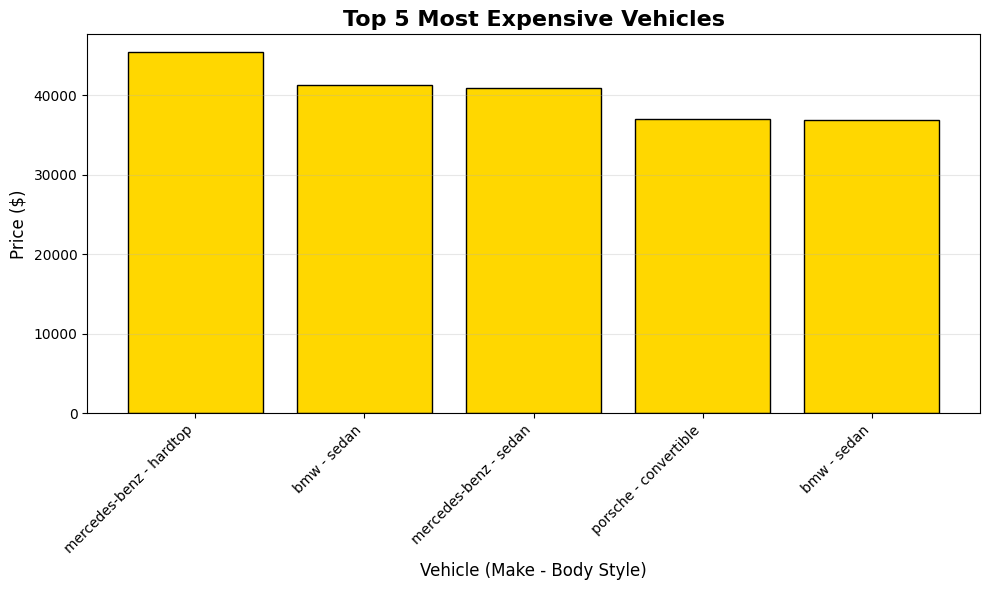

In [86]:
# Code here
top_5_expensive = automobiles_df.nlargest(5, 'price')
print(top_5_expensive)

top_5_expensive = automobiles_df.nlargest(5, 'price')

# Create vehicle labels
vehicle_labels = top_5_expensive['make'] + ' - ' + top_5_expensive['body-style']

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(range(len(top_5_expensive)), top_5_expensive['price'], color='gold', edgecolor='black')
plt.xticks(range(len(top_5_expensive)), vehicle_labels, rotation=45, ha='right')
plt.title('Top 5 Most Expensive Vehicles', fontsize=16, fontweight='bold')
plt.xlabel('Vehicle (Make - Body Style)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

Average Highway MPG by Manufacturer:
make
chevrolet        46.333333
isuzu            36.000000
honda            35.461538
volkswagen       34.916667
plymouth         34.142857
dodge            34.111111
nissan           32.944444
toyota           32.906250
mazda            31.941176
mitsubishi       31.153846
renault          31.000000
subaru           30.750000
saab             27.333333
alfa-romero      26.666667
peugot           26.636364
porsche          26.000000
volvo            25.818182
bmw              25.375000
audi             24.142857
mercury          24.000000
mercedes-benz    21.000000
jaguar           18.333333
Name: highway-mpg, dtype: float64


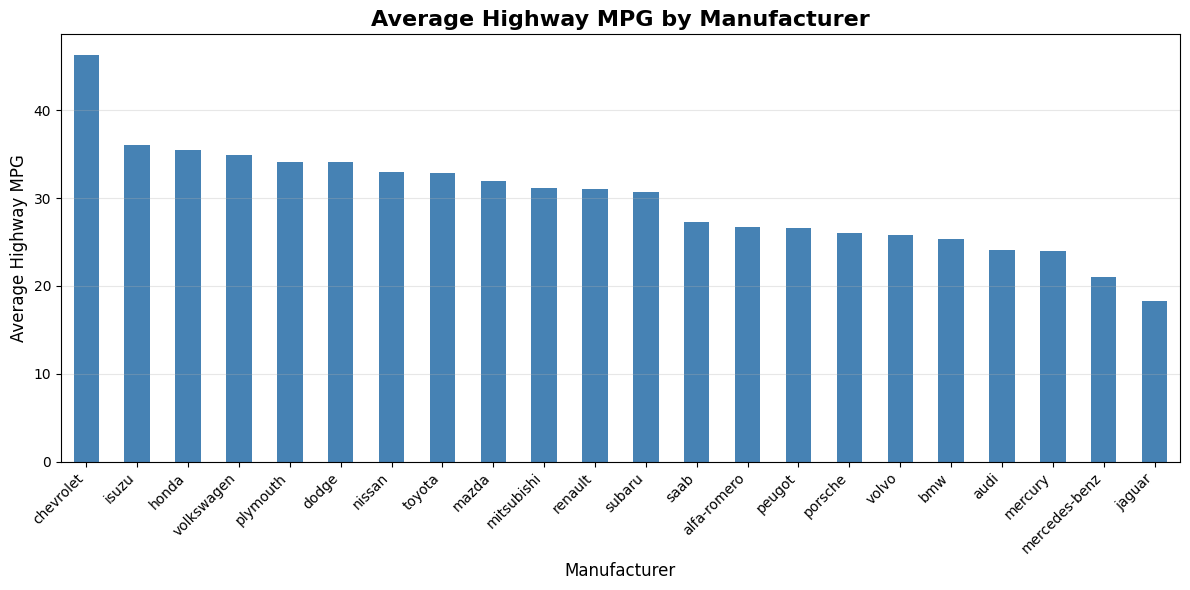


Top 5 Most Fuel-Efficient Manufacturers:
make
chevrolet     46.333333
isuzu         36.000000
honda         35.461538
volkswagen    34.916667
plymouth      34.142857
Name: highway-mpg, dtype: float64


In [87]:
# Code here
import matplotlib.pyplot as plt

# Calculate average MPG for each manufacturer
avg_mpg_by_make = automobiles_df.groupby('make')['highway-mpg'].mean().sort_values(ascending=False)

print("Average Highway MPG by Manufacturer:")
print(avg_mpg_by_make)

# Create bar plot
plt.figure(figsize=(12, 6))
avg_mpg_by_make.plot(kind='bar', color='steelblue')
plt.title('Average Highway MPG by Manufacturer', fontsize=16, fontweight='bold')
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Average Highway MPG', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Top 5 most fuel-efficient manufacturers
print("\nTop 5 Most Fuel-Efficient Manufacturers:")
print(avg_mpg_by_make.head())



#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

             make   body-style  engine-size num-of-cylinders  horsepower  \
49         jaguar        sedan          326           twelve         262   
73  mercedes-benz        sedan          308            eight         184   
74  mercedes-benz      hardtop          304            eight         184   
48         jaguar        sedan          258              six         176   
47         jaguar        sedan          258              six         176   
71  mercedes-benz        sedan          234            eight         155   
72  mercedes-benz  convertible          234            eight         155   
16            bmw        sedan          209              six         182   
17            bmw        sedan          209              six         182   
15            bmw        sedan          209              six         182   

    price  
49  36000  
73  40960  
74  45400  
48  35550  
47  32250  
71  34184  
72  35056  
16  41315  
17  36880  
15  30760  


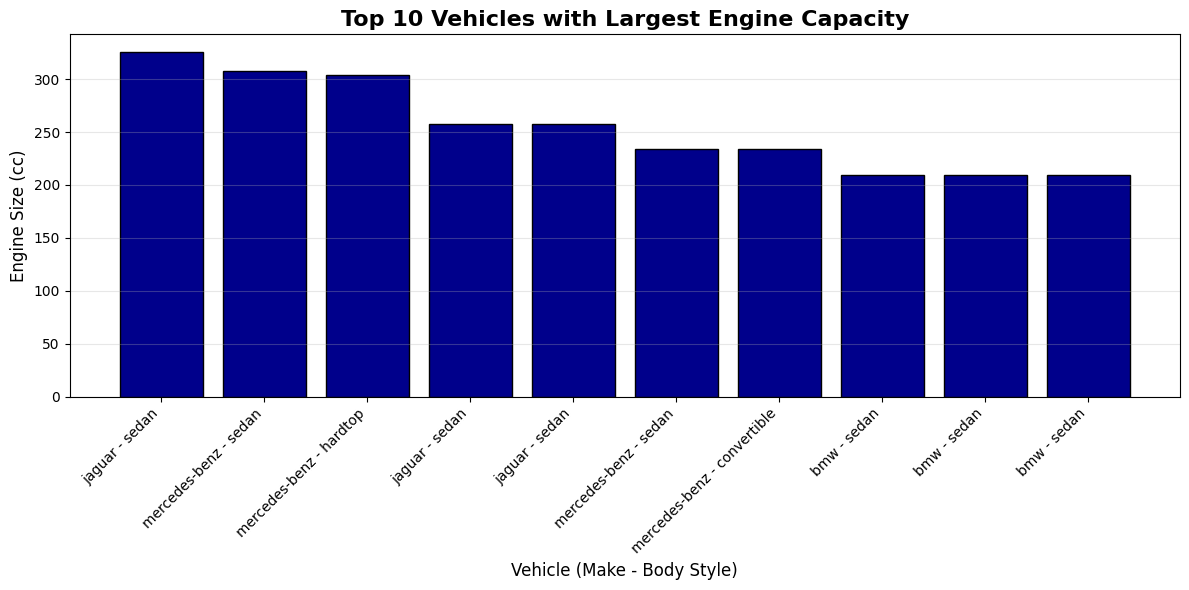

In [75]:
# Code here
# Dataframe sorted by engine capacity (largest first)
largest_engine_capacity = automobiles_df.sort_values('engine-size', ascending=False)

# View with the columns
print(largest_engine_capacity[['make', 'body-style', 'engine-size', 'num-of-cylinders', 'horsepower', 'price']].head(10))

top_10_engine = largest_engine_capacity.head(10)
vehicle_labels = top_10_engine['make'] + ' - ' + top_10_engine['body-style']

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_10_engine)), top_10_engine['engine-size'], color='darkblue', edgecolor='black')
plt.xticks(range(len(top_10_engine)), vehicle_labels, rotation=45, ha='right')
plt.title('Top 10 Vehicles with Largest Engine Capacity', fontsize=16, fontweight='bold')
plt.xlabel('Vehicle (Make - Body Style)', fontsize=12)
plt.ylabel('Engine Size (cc)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Which vehicle manufacturer has the most car models in the dataset

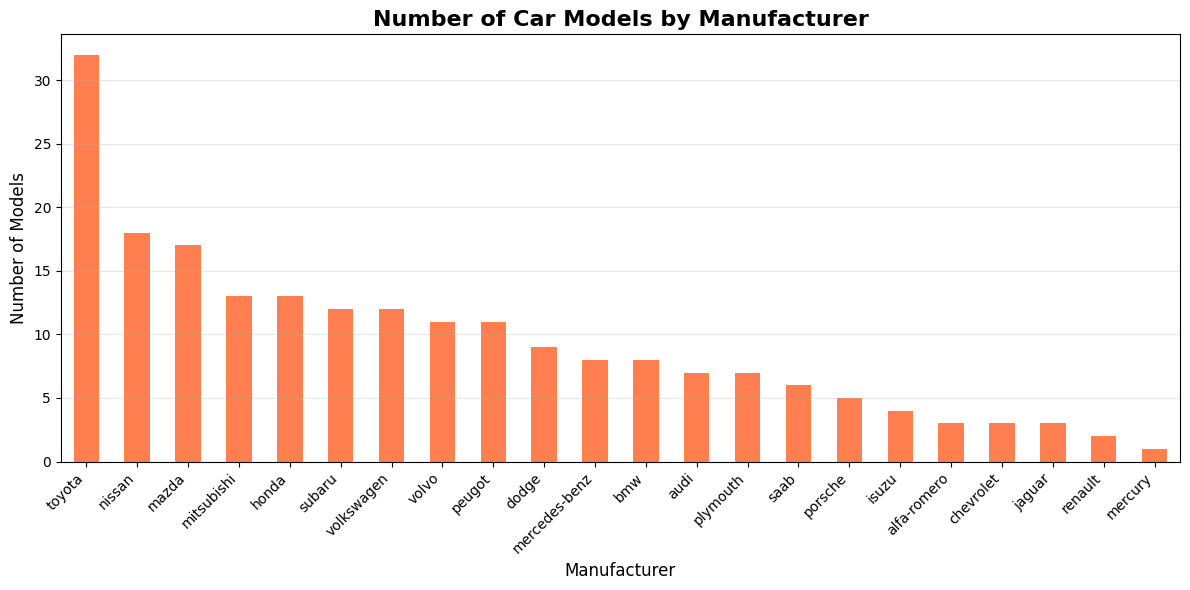

In [76]:
# Code here

# Count and plot
cars_per_make = automobiles_df['make'].value_counts()

plt.figure(figsize=(12, 6))
cars_per_make.plot(kind='bar', color='coral')
plt.title('Number of Car Models by Manufacturer', fontsize=16, fontweight='bold')
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


3. **Data Visualization and Insights**

 3.1 Price Analysis - Most Expensive Vehicles

**Analysis:**
Identified the top 5 most expensive vehicles in the dataset to understand the premium segment.



**Key Observations:**
- Mercedes-Benz dominates the luxury segment with multiple models in top 5
- Price range: $[min] to $[max]
- Premium vehicles tend to have [larger engines/specific body styles/etc.]

### 3.2 Fuel Efficiency - Manufacturer Comparison

**Analysis:**
Compared average highway MPG across all manufacturers to identify fuel efficiency leaders.

[Include your bar plot here]

**Key Observations:**
- [Manufacturer X] produces the most fuel-efficient vehicles with average [X] MPG
- Clear variation across manufacturers
- Fuel efficiency appears to correlate with [engine size/vehicle type/etc.]

### 3.3 Engine Performance - Largest Engine Capacity

**Analysis:**
Examined vehicles with the largest engine capacity to understand performance characteristics.

[Include your graph here]

**Key Observations:**
- Largest engine sizes found in [body styles/manufacturers]
- Engine capacity ranges from [min] to [max] cc
- Relationship between engine size and [price/fuel efficiency/etc.]

### 3.4 Market Distribution - Manufacturer Presence

**Analysis:**
Analyzed which manufacturers have the most car models in the dataset.

[Include your visualization here]

**Key Observations:**
- [Manufacturer X] has the most models with [count] vehicles
- Market diversity: [number] different manufacturers represented
- [Pattern observed about market distribution]

This report was written by Lerato kgosimore